1.	Exploratory Data Analysis (EDA)
- Visualize trends, seasonality, and anomalies in the milk production data.
- Check for any missing values or outliers.
- Normalize or scale the data for neural network models.



In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import keras
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization,Embedding

In [109]:
df = pd.read_csv('monthly_milk_production.csv')

In [110]:
df.shape

(168, 2)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [112]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [113]:
df1 = pd.read_csv('monthly_milk_production.csv',parse_dates=['Date'],index_col='Date')

In [114]:
df1.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


Text(0.5, 1.0, 'Monthly Milk Production')

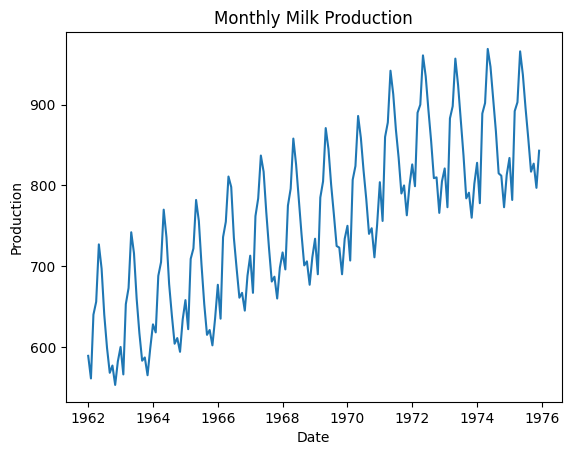

In [115]:
plt.plot(df1['Production'])
plt.xlabel('Date')
plt.ylabel('Production')
plt.title('Monthly Milk Production')

Trend :
- The time series plot shows a clear upward trend in milk production from 1962 to around 1973, after which the trend continues with slight fluctuations.

Seasonality :
- The data shows strong seasonality, with a repeating annual pattern indicating peaks and troughs occurring at regular 12-month intervals.

Anomalies :
- No significant anomalies or outliers are observed, as the variations in the data follow consistent seasonal behavior.

In [116]:
df1.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [117]:
df1.isnull().sum()

,0
Production,0


There is no null values

In [118]:
from sklearn.preprocessing import MinMaxScaler

In [119]:
min_max = MinMaxScaler()

In [120]:
df1['Production'] = min_max.fit_transform(df1[['Production']])

In [121]:
df1.head()

,Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269


2.	Data Preparation for Deep Learning
-	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
-	Split data into training, validation, and test sets.
-	Reshape data for model input dimensions.


In [122]:
## Convert the scaled production column into array
data = df1['Production'].values
data

array([0.08653846, 0.01923077, 0.20913462, 0.24759615, 0.41826923,
       0.34615385, 0.20913462, 0.11057692, 0.03605769, 0.05769231,
       0.        , 0.06971154, 0.11298077, 0.03125   , 0.24038462,
       0.28846154, 0.45432692, 0.39182692, 0.25721154, 0.15384615,
       0.07211538, 0.08173077, 0.02884615, 0.10817308, 0.18028846,
       0.15625   , 0.32451923, 0.36538462, 0.52163462, 0.43990385,
       0.30048077, 0.20673077, 0.12259615, 0.13942308, 0.09855769,
       0.19471154, 0.25240385, 0.16586538, 0.375     , 0.40625   ,
       0.55048077, 0.48798077, 0.35817308, 0.24038462, 0.14903846,
       0.16346154, 0.11778846, 0.19711538, 0.29807692, 0.19711538,
       0.43990385, 0.48557692, 0.62019231, 0.58894231, 0.4375    ,
       0.34615385, 0.25961538, 0.27403846, 0.22115385, 0.32451923,
       0.38461538, 0.27403846, 0.50240385, 0.55528846, 0.68269231,
       0.63461538, 0.51442308, 0.40625   , 0.30769231, 0.32211538,
       0.25721154, 0.34855769, 0.39423077, 0.34375   , 0.53365

In [123]:
len(data)

168

In [124]:
168-12

156

In [125]:
## Sequence creation, i use window size = 12 because the seasonality is 1 year
window_size = 12
x1 = []
y1 = []
for i in range(len(data) - window_size):
  x1.append(data[i:i+window_size])
  y1.append(data[i+window_size])

In [126]:
## Convert to array
x1 = np.array(x1)
y1 = np.array(y1)

In [127]:
x1.shape

(156, 12)

In [128]:
y1.shape

(156,)

In [129]:
## Reshaping
x1 = x1.reshape((x1.shape[0], x1.shape[1], 1))

In [130]:
print(x1.shape)
print(y1.shape)

(156, 12, 1)
(156,)


In [131]:
n = len(x1)
train_size = int(0.7*n)
validation_size = int(0.15*n)

In [132]:
## Train set
x_train1 = x1[:train_size]
y_train1 = y1[:train_size]

In [133]:
## validation size
x_val1 = x1[train_size : train_size + validation_size]
y_val1 = y1[train_size : train_size + validation_size]

In [134]:
## Test size
x_test1 = x1[train_size + validation_size:]
y_test1 = y1[train_size + validation_size:]

In [135]:
print(x_train1.shape, y_train1.shape)
print(x_val1.shape, y_val1.shape)
print(x_test1.shape, y_test1.shape)

(109, 12, 1) (109,)
(23, 12, 1) (23,)
(24, 12, 1) (24,)


3.	Model Building
-	Build three separate models:

	Basic RNN

	LSTM
  
  GRU
-	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).
-	Use appropriate loss functions and optimizers.


In [136]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,LSTM,GRU,Dense

In [137]:
## RNN Model

In [138]:
## Model building
rnn = Sequential()
rnn.add(SimpleRNN(units=50,activation='tanh',input_shape=(x_train1.shape[1], 1)))
rnn.add(Dense(1))

In [139]:
rnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [140]:
## Model compilation
rnn.compile(optimizer='adam',loss='mse')

In [141]:
## Train the model
history = rnn.fit(x_train1,y_train1,epochs=20,batch_size=16,validation_data=(x_val1,y_val1))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0951 - val_loss: 0.0385
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0296 - val_loss: 0.0402
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0186 - val_loss: 0.0445
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0079 - val_loss: 0.0037
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0033 - val_loss: 0.0151
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_loss: 0.0073
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0026 - val_loss: 0.0066
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0058
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0023 - val_loss: 0.0050
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - val_loss: 0.0048
E

In [142]:
y_pred1 = rnn.predict(x_test1)
y_pred1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


array([[0.6372072 ],
       [0.61735666],
       [0.7135211 ],
       [0.76708883],
       [0.89590573],
       [0.8720404 ],
       [0.77858514],
       [0.7141913 ],
       [0.6041201 ],
       [0.5925379 ],
       [0.5388737 ],
       [0.5700491 ],
       [0.64036536],
       [0.62144506],
       [0.71143365],
       [0.76407695],
       [0.89823234],
       [0.8843044 ],
       [0.7959223 ],
       [0.73772967],
       [0.63737255],
       [0.6234203 ],
       [0.56875116],
       [0.6023016 ]], dtype=float32)

In [175]:
y_pred1 = min_max.inverse_transform(y_pred1)

In [143]:
## LSTM model

In [144]:
lstm = Sequential()


In [145]:
lstm.add(LSTM(units=50, activation='tanh', input_shape=(x_train1.shape[1], 1)))
lstm.add(Dense(1))

In [155]:
lstm.compile(optimizer='adam',loss='mse')

In [147]:
history1 = lstm.fit(x_train1,y_train1,epochs=50,batch_size=16,validation_data=(x_val1,y_val1))

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1586 - val_loss: 0.2223
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0566 - val_loss: 0.0436
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0298 - val_loss: 0.0330
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307 - val_loss: 0.0273
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0247 - val_loss: 0.0415
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0264 - val_loss: 0.0402
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0256 - val_loss: 0.0282
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0243 - val_loss: 0.0273
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0239 - val_loss: 0.0293
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0235 - val_loss: 0.0280
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0232 - val_loss: 0.0272
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0230 - val_loss: 0.025

In [176]:
y_pred2 = lstm.predict(x_test1)
y_pred2 = min_max.inverse_transform(y_pred2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


In [149]:
## GRU Model
gru = Sequential()
gru.add(GRU(units=50,activation='tanh',input_shape=(x_train1.shape[1],1)))
gru.add(Dense(1))

In [150]:
gru.compile(optimizer='adam',loss='mse')
history3 = gru.fit(x_train1,y_train1,epochs=20,batch_size=16,validation_data=(x_val1,y_val1))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.1415 - val_loss: 0.1695
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0382 - val_loss: 0.0312
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0290 - val_loss: 0.0249
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0304 - val_loss: 0.0275
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0231 - val_loss: 0.0408
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0239 - val_loss: 0.0451
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0233 - val_loss: 0.0369
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0220 - val_loss: 0.0288
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0217 - val_loss: 0.0263
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0210 - val_loss: 0.0297
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0204 - val_loss: 0.0296
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0198 - val_loss: 0.0278
E

In [178]:
y_pred3 = gru.predict(x_test1)
y_pred3 = min_max.inverse_transform(y_pred3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [153]:
## Changing the window size into 24

In [152]:
window_size = 24
x2 = []
y2 = []
for i in range(len(data) - window_size):
  x2.append(data[i:i+window_size])
  y2.append(data[i+window_size])

In [154]:
x2 = np.array(x2)
y2 = np.array(y2)

In [156]:
x2 = x2.reshape((x2.shape[0], x2.shape[1], 1))
print(x1.shape)
print(y1.shape)

(156, 12, 1)
(156,)


In [157]:
n = len(x2)
train_size = int(0.7*n)
validation_size = int(0.15*n)

In [158]:
x_train2 = x2[:train_size]
y_train2 = y2[:train_size]

x_val2 = x2[train_size : train_size + validation_size]
y_val2 = y2[train_size : train_size + validation_size]

x_test2 = x2[train_size + validation_size:]
y_test2 = y2[train_size + validation_size:]

In [159]:
print(x_train2.shape, y_train2.shape)
print(x_val2.shape, y_val2.shape)
print(x_test2.shape, y_test2.shape)

(100, 24, 1) (100,)
(21, 24, 1) (21,)
(23, 24, 1) (23,)


In [160]:
## RNN Model 2

In [164]:
rnn2 = Sequential()
rnn2.add(SimpleRNN(units=20,activation='tanh',input_shape=(x_train2.shape[1], 1)))
rnn2.add(Dense(1))
rnn2.compile(optimizer='adam',loss='mse')
history1 = rnn2.fit(x_train2,y_train2,epochs=50,batch_size=8,validation_data=(x_val2,y_val2))

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0236 - val_loss: 0.0189
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0135 - val_loss: 0.0105
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0089 - val_loss: 0.0081
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0064 - val_loss: 0.0062
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0038 - val_loss: 0.0046
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0034 - val_loss: 0.0048
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0040
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0036
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0031 - val_loss: 0.0034
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.00

In [179]:
y_pred12 = rnn2.predict(x_test2)
y_pred12 = min_max.inverse_transform(y_pred12)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [161]:
## LSTM Model 1

In [166]:
lstm2 = Sequential()
lstm2.add(LSTM(units=20, activation='tanh', input_shape=(x_train2.shape[1], 1)))
lstm2.add(Dense(1))
lstm2.compile(optimizer='adam',loss='mse')
history11 = lstm.fit(x_train2,y_train2,epochs=20,batch_size=8,validation_data=(x_val2,y_val2))

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.3749 - val_loss: 0.2353
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0772 - val_loss: 0.0194
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0270 - val_loss: 0.0228
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0167 - val_loss: 0.0481
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0164 - val_loss: 0.0268
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0163 - val_loss: 0.0278
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - val_loss: 0.0245
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0146 - val_loss: 0.0263
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0142 - val_loss: 0.0238
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0141 - val_loss: 0.0238
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0142 - val_loss: 0.0245
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0

In [180]:
y_pred21 = lstm.predict(x_test2)
y_pred21 = min_max.inverse_transform(y_pred21)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [162]:
## LSTM Model 2

In [168]:
gru2 = Sequential()
gru2.add(GRU(units=20,activation='tanh',input_shape=(x_train2.shape[1],1)))
gru2.add(Dense(1))
gru2.compile(optimizer='adam',loss='mse')
history31 = gru2.fit(x_train2,y_train2,epochs=50,batch_size=8,validation_data=(x_val2,y_val2))

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3530 - val_loss: 0.5926
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1823 - val_loss: 0.3072
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0793 - val_loss: 0.1288
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0340 - val_loss: 0.0504
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0356 - val_loss: 0.0353
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0319 - val_loss: 0.0524
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0306 - val_loss: 0.0536
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0297 - val_loss: 0.0481
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0286 - val_loss: 0.0446
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0279 - val_loss: 0.0426
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0271 - val_loss: 0.0416
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

In [181]:
y_pred31 = gru2.predict(x_test2)
y_pred31 = min_max.inverse_transform(y_pred31)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


4.	Model Evaluation
-	Plot predictions vs. actual values.
-	Calculate forecasting metrics: RMSE, MAE, MAPE.
-	Compare the performance of RNN, LSTM, and GRU.


In [170]:
## RNN

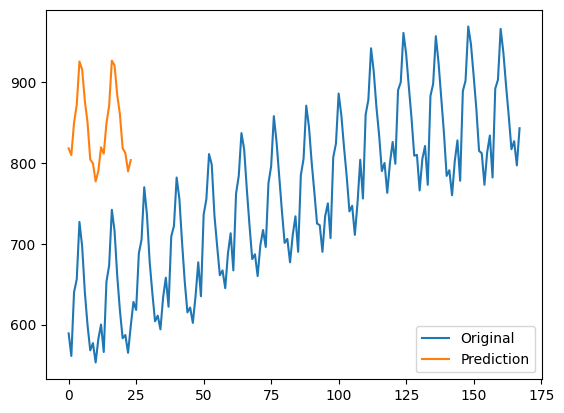

In [182]:
## Model 1
plt.plot(df['Production'],label='Original')
plt.plot(y_pred1,label='Prediction')
plt.legend()
plt.show()

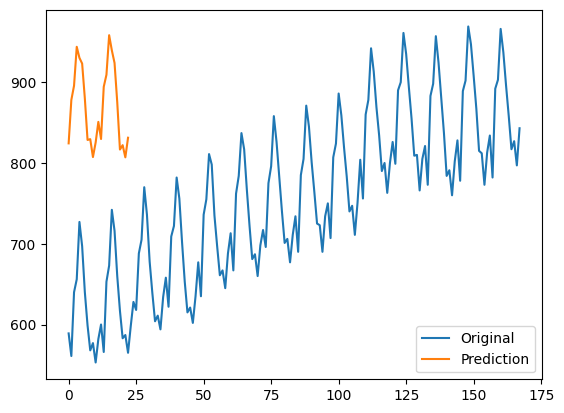

In [183]:
## Model 2
plt.plot(df['Production'],label='Original')
plt.plot(y_pred12,label='Prediction')
plt.legend()
plt.show()

In [184]:
## LSTM

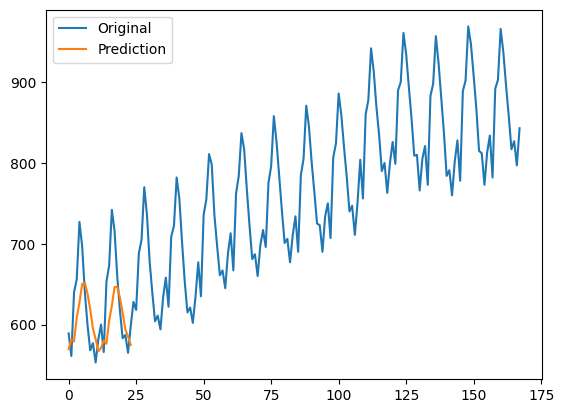

In [185]:
## Model 1
plt.plot(df['Production'],label='Original')
plt.plot(y_pred2,label='Prediction')
plt.legend()
plt.show()

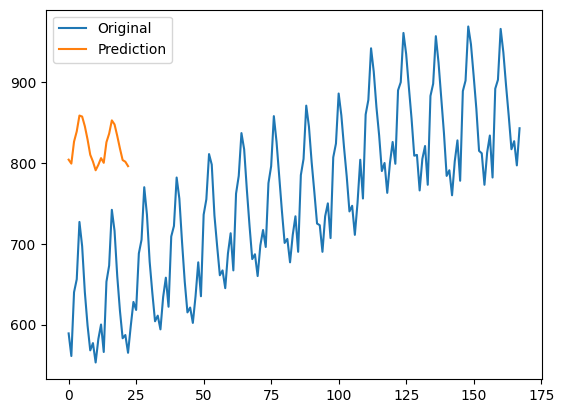

In [187]:
## Model 2
plt.plot(df['Production'],label='Original')
plt.plot(y_pred21,label='Prediction')
plt.legend()
plt.show()

In [188]:
## GRU

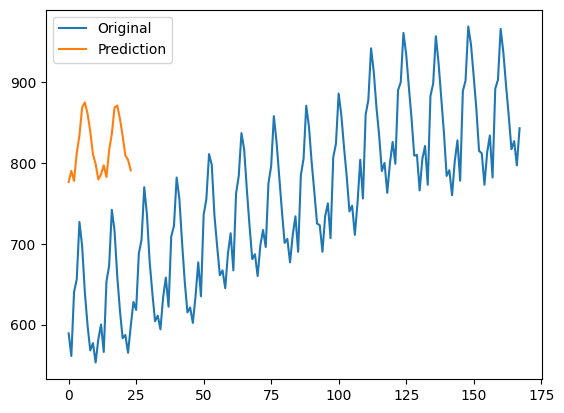

In [189]:
## Model 1
plt.plot(df['Production'],label='Original')
plt.plot(y_pred3,label='Prediction')
plt.legend()
plt.show()

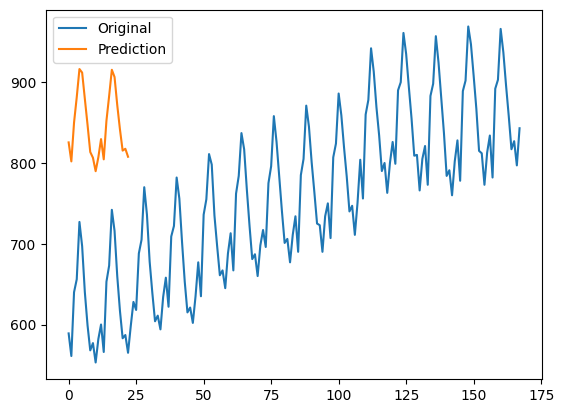

In [190]:
## Model 2
plt.plot(df['Production'],label='Original')
plt.plot(y_pred31,label='Prediction')
plt.legend()
plt.show()

In [191]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [196]:
## RNN Model 1
rmse1 = root_mean_squared_error(y_test1,y_pred1)
mae1 = mean_absolute_error(y_test1,y_pred1)
mape1 = mean_absolute_percentage_error(y_test1,y_pred1)
print('RMSE : ',rmse1,'\nMAE : ',mae1,'\nMAPE : ',mape1)

RMSE :  844.4549078199474 
MAE :  843.2324756720128 
MAPE :  1171.0655291403261


In [197]:
## RNN Model 2
rmse12 = root_mean_squared_error(y_test2,y_pred12)
mae12 = mean_absolute_error(y_test2,y_pred12)
mape12 = mean_absolute_percentage_error(y_test2,y_pred12)
print('RMSE : ',rmse12,'\nMAE : ',mae12,'\nMAPE : ',mape12)

RMSE :  871.1812883168528 
MAE :  869.8319885866298 
MAPE :  1203.0027605556074


In [198]:
## LSTM Model 1
rmse2 = root_mean_squared_error(y_test1,y_pred2)
mae2 = mean_absolute_error(y_test1,y_pred2)
mape2 = mean_absolute_percentage_error(y_test1,y_pred2)
print('RMSE : ',rmse2,'\nMAE : ',mae2,'\nMAPE : ',mape2)

RMSE :  604.8138346488945 
MAE :  604.1559706467848 
MAPE :  842.310512030428


In [199]:
## LSTM Model 2
rmse21 = root_mean_squared_error(y_test2,y_pred21)
mae21 = mean_absolute_error(y_test2,y_pred21)
mape21 = mean_absolute_percentage_error(y_test2,y_pred21)
print('RMSE : ',rmse21,'\nMAE : ',mae21,'\nMAPE : ',mape21)

RMSE :  820.4802899024451 
MAE :  820.202578133165 
MAPE :  1141.9860961551617


In [200]:
## GRU Model 1
rmse3 = root_mean_squared_error(y_test1,y_pred3)
mae3 = mean_absolute_error(y_test1,y_pred3)
mape3 = mean_absolute_percentage_error(y_test1,y_pred3)
print('RMSE : ',rmse3,'\nMAE : ',mae3,'\nMAPE : ',mape3)

RMSE :  819.6618071946849 
MAE :  819.0181786952876 
MAPE :  1143.654632666556


In [201]:
## GRU Model 2
rmse31 = root_mean_squared_error(y_test2,y_pred31)
mae31 = mean_absolute_error(y_test2,y_pred31)
mape31 = mean_absolute_percentage_error(y_test2,y_pred31)
print('RMSE : ',rmse31,'\nMAE : ',mae31,'\nMAPE : ',mape31)

RMSE :  846.9838855389697 
MAE :  846.0364696285795 
MAPE :  1174.8166288759783


Best Model:

LSTM (window = 12)
- Lowest RMSE: 604
- Lowest MAE: 604
- Lowest MAPE: 842
- Clearly the best performing model

Effect of Window size
- Window = 12 , perfectly captures pattern
- Window = 24 , adds noise, harder to learn

Among all models, the LSTM with a window size of 12 achieved the best performance, with the lowest error values across all metrics. This indicates its superior ability to capture long-term dependencies and seasonal patterns in the data. The GRU model performed better than the basic RNN but was slightly less accurate than LSTM. The basic RNN showed the weakest performance due to its limitations in handling long-term dependencies. Additionally, increasing the window size from 12 to 24 resulted in worse performance across all models, suggesting that a window size of 12 is optimal for capturing the annual seasonality present in the dataset.

5.	Prediction and Visualization
-	Forecast milk production for the next 12 months.
-	Visualize the predicted trend with uncertainty or confidence intervals if possible.


In [207]:
window_size = 12
last_sequence = data[-window_size:]
last_sequence.shape

(12,)

In [208]:
print(x_train1.shape)

(109, 12, 1)


In [210]:
## Reshape for model
last_sequence = last_sequence.reshape((1, window_size, 1))

In [211]:
## Predict next 12 months
future_predictions = []
current_sequence = last_sequence.copy()
for _ in range(12):
    next_value = lstm2.predict(current_sequence)[0][0]
    future_predictions.append(next_value)
    current_sequence = np.append(current_sequence[:,1:,:], [[[next_value]]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [212]:
## Convert back to original scale
future_predictions = np.array(future_predictions).reshape(-1,1)
future_predictions_actual = min_max.inverse_transform(future_predictions)

In [214]:
## Create future dates
last_date = df1.index[-1]
future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]
future_dates

DatetimeIndex(['1976-01-31', '1976-02-29', '1976-03-31', '1976-04-30',
               '1976-05-31', '1976-06-30', '1976-07-31', '1976-08-31',
               '1976-09-30', '1976-10-31', '1976-11-30', '1976-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [216]:
errors = y_test1 - y_pred2

In [217]:
std_dev = np.std(errors)

In [218]:
upper_bound = future_predictions_actual + 1.96 * std_dev
lower_bound = future_predictions_actual - 1.96 * std_dev

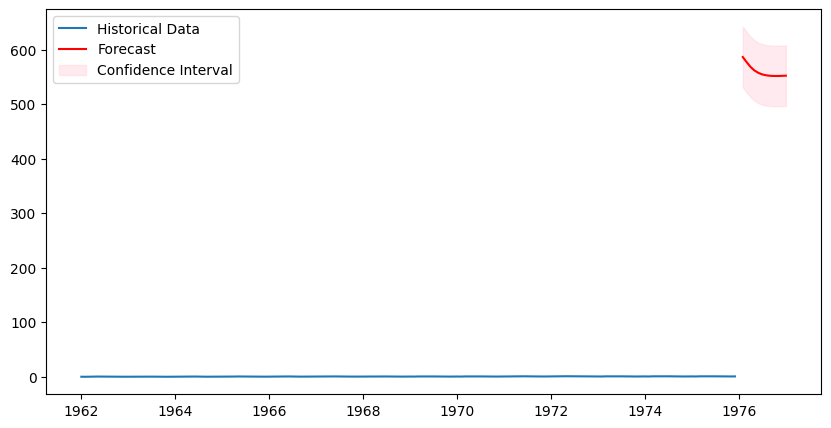

In [220]:
plt.figure(figsize=(10,5))
plt.plot(df1['Production'], label='Historical Data')
plt.plot(future_dates, future_predictions_actual, label='Forecast', color='red')
plt.fill_between(
    future_dates,
    lower_bound.flatten(),
    upper_bound.flatten(),
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

plt.legend()
plt.show()

6.	Business Insights
-	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

The LSTM model demonstrated the best performance in forecasting milk production, effectively capturing seasonal patterns and long-term dependencies in the data. The forecasts indicate a consistent seasonal trend, allowing the dairy business to anticipate fluctuations in production.

These predictions can be used for efficient demand planning, inventory management, and resource allocation. During high production periods, the business can increase storage capacity and process excess milk into long-lasting products such as butter and cheese. During low production periods, stored products can be utilized to meet demand.

Additionally, the forecasts support better pricing strategies, workforce planning, and supply chain optimization. The inclusion of uncertainty through confidence intervals further helps in risk management by preparing the business for potential variations in production. Overall, the forecasting model enables data-driven decision-making, improving operational efficiency and reducing waste.
